In [16]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def show_match(img1, kp1, img2, kp2, matches, title):
    # Draw matches
    matched_img = cv2.drawMatches(
        img1, kp1, 
        img2, kp2, 
        matches, None, 
        flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS,
        matchColor=(0, 255, 0)
    )

    # Convert BGR->RGB if images are BGR
    matched_img_rgb = cv2.cvtColor(matched_img, cv2.COLOR_BGR2RGB)
    
    plt.figure(figsize=(12,6))
    plt.title(title)
    plt.imshow(matched_img_rgb)
    plt.axis('off')
    plt.show()

# Read images
boat1_color = cv2.imread('Assignment3_Files/boat1.jpg')
boat3_color = cv2.imread('Assignment3_Files/boat3.jpg')

# Convert to grayscale
boat1_gray = cv2.cvtColor(boat1_color, cv2.COLOR_BGR2GRAY)
boat3_gray = cv2.cvtColor(boat3_color, cv2.COLOR_BGR2GRAY)


In [17]:
# Initialize ORB
orb = cv2.ORB_create(nfeatures=500)

# Detect and compute
kp1, des1 = orb.detectAndCompute(boat1_gray, None)
kp3, des3 = orb.detectAndCompute(boat3_gray, None)

print(f"Number of keypoints in boat1: {len(kp1)}")
print(f"Number of keypoints in boat3: {len(kp3)}")


Number of keypoints in boat1: 500
Number of keypoints in boat3: 500


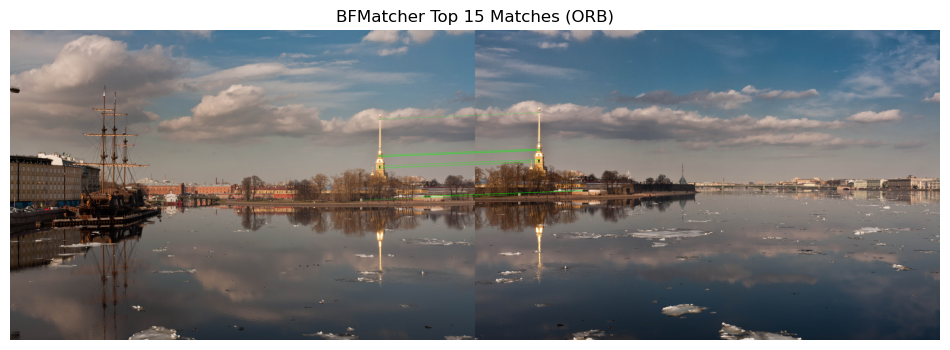

In [18]:
# BFMatcher with Hamming norm
bf = cv2.BFMatcher(cv2.NORM_HAMMING, crossCheck=True)

# Match descriptors
matches_bf = bf.match(des1, des3)

# Sort them in ascending order of distance
matches_bf = sorted(matches_bf, key=lambda x: x.distance)

# Show top 15 matches
top_15_bf = matches_bf[:15]
show_match(boat1_color, kp1, boat3_color, kp3, top_15_bf, "BFMatcher Top 15 Matches (ORB)")


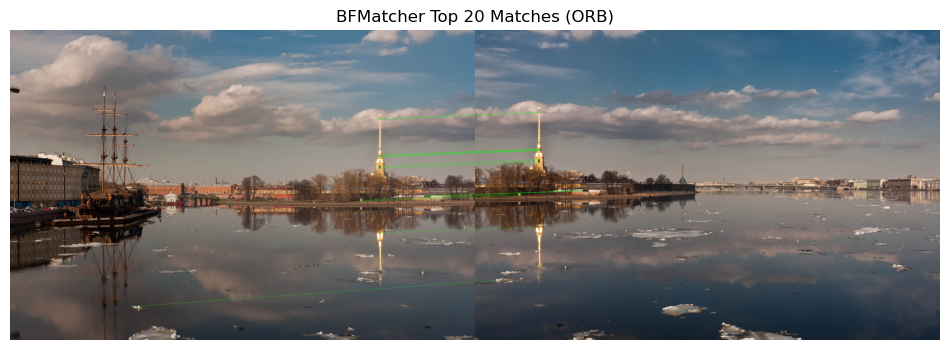

In [19]:
# Show top 20 matches
top_20_bf = matches_bf[:20]
show_match(boat1_color, kp1, boat3_color, kp3, top_20_bf, "BFMatcher Top 20 Matches (ORB)")

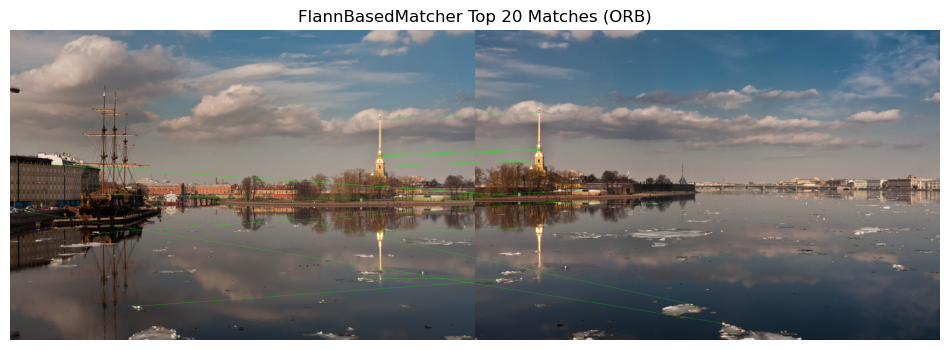

In [20]:
# FLANN for ORB
FLANN_INDEX_LSH = 1
index_params= dict(algorithm = FLANN_INDEX_LSH,
                   table_number = 6,
                   key_size = 12,
                   multi_probe_level = 1)
search_params = dict(checks=50)

flann = cv2.FlannBasedMatcher(index_params, search_params)

# With ORB, pass descriptors as type float32
des1_float = np.float32(des1)
des3_float = np.float32(des3)

matches_flann = flann.match(des1_float, des3_float)
matches_flann = sorted(matches_flann, key=lambda x: x.distance)

# Show top 20 matches
top_20_flann = matches_flann[:20]
show_match(boat1_color, kp1, boat3_color, kp3, top_20_flann, "FlannBasedMatcher Top 20 Matches (ORB)")


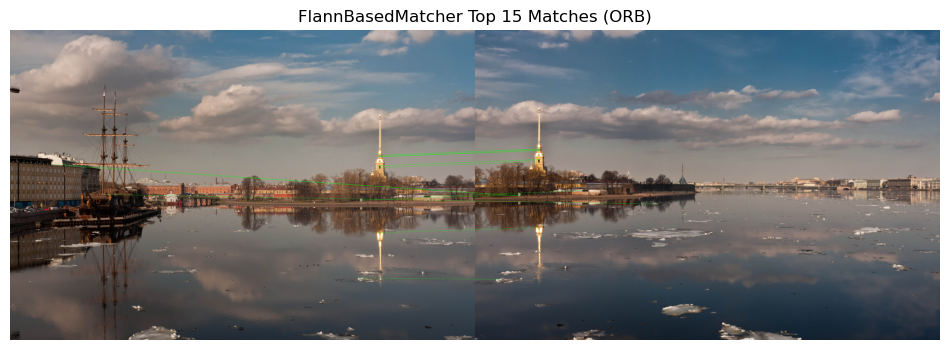

In [21]:
# Show top 15 matches
top_15_flann = matches_flann[:15]
show_match(boat1_color, kp1, boat3_color, kp3, top_15_flann, "FlannBasedMatcher Top 15 Matches (ORB)")

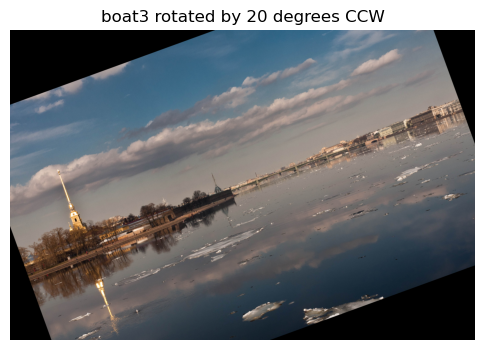

In [14]:
# Get image dimensions
h, w = boat3_gray.shape[:2]
center = (w//2, h//2)

# Rotation matrix: 20 deg CCW
angle = 20
rotation_matrix = cv2.getRotationMatrix2D(center, angle, 1.0)

# Perform the rotation
boat3_rotated_color = cv2.warpAffine(boat3_color, rotation_matrix, (w, h))
boat3_rotated_gray = cv2.cvtColor(boat3_rotated_color, cv2.COLOR_BGR2GRAY)

# Display the rotated image
plt.figure(figsize=(6,6))
plt.title("boat3 rotated by 20 degrees CCW")
plt.imshow(cv2.cvtColor(boat3_rotated_color, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.show()


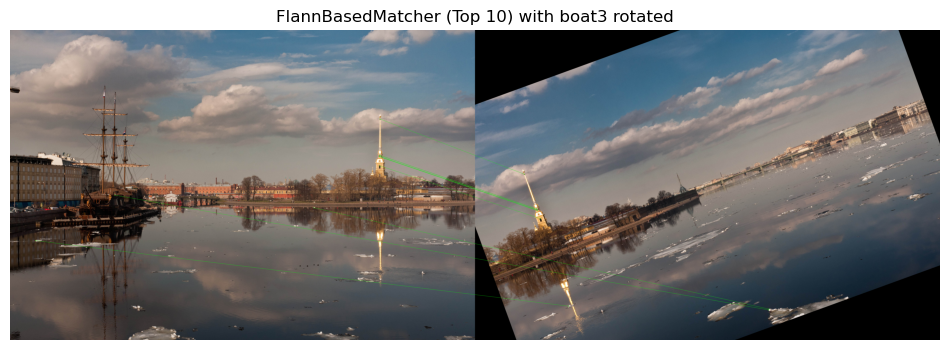

In [15]:
# Detect features in the rotated image
kp3_rot, des3_rot = orb.detectAndCompute(boat3_rotated_gray, None)

# Convert descriptors to float32 for FLANN
des3_rot_float = np.float32(des3_rot)

# Match with Flann
matches_flann_rot = flann.match(des1_float, des3_rot_float)
matches_flann_rot = sorted(matches_flann_rot, key=lambda x: x.distance)

top_10_flann_rot = matches_flann_rot[:10]
show_match(boat1_color, kp1, boat3_rotated_color, kp3_rot, top_10_flann_rot, 
           "FlannBasedMatcher (Top 10) with boat3 rotated")
